# 11 - Tomasov et al. 2025 CNN Baseline (their architecture, our splits)

A faithful reproduction of the CNN from *"Advancing Perimeter Security: Integrating DAS
and CNN for Object Classification in Fiber Vicinity"*, IEEE Access 13 (2025) - the paper
that accompanies this dataset. No code was released, so everything below is transcribed
from the text and cited to a section.

## What their paper specifies

**Section III-C - the CNN does NOT see raw signals.** Verbatim: *"Directly classifying
raw signals poses significant challenges due to sampling rate incompatibility,
time-domain complexity, and inadequate normalization."* They apply one of three
transforms first:

| transform | their spec | their result |
|---|---|---|
| **RDFT** | zero-pad, FFT, log10 magnitude, subtract mean, truncate to 2048 bins (0-833 Hz) | 85.47% acc, **84.84% F1 (best)** |
| MFCC | librosa, then StandardScaler | **85.61% acc (best)**, high cost |
| DWT | level 3, Daubechies-4, then StandardScaler | 78.48% acc, 75.84% F1 |

**Section III-E - the architecture.** *"two convolutional layers... The first layer
contains 64 filters, while the second one 256. LeakyReLU is applied after each...
max pooling with a pool size of 4 after each... flattened... a dense layer with 256
neurons, which uses a sigmoid activation function. Finally, an output layer... softmax."*

**Section IV - training.** Adam optimiser; loss-function class weights to address
imbalance; 80/10/10 splits.

## Two corrections to the earlier baseline

1. It fed the CNN a **decimated raw waveform** - exactly the input their paper rules out.
2. It used **`Dense(1024)`** (33,155,849 parameters, matching Table 21 of our
   manuscript). The Access paper says **256 neurons** -> 8,375,561 parameters. We report
   both, so the previously published figure remains traceable.

## One inference we had to make

The paper's Table 2 does not survive text extraction from the PDF, so the RDFT
redundancy factor is derived from two stated facts: the output is truncated to 2048 bins
and that corresponds to 0-833 Hz. At fs = 20 kHz this needs an FFT length of
20000 x 2048 / 833 ~ 49152 = 6 x 8192, i.e. **redundancy factor 6**. This is recorded as
an assumption, and `B.RDFT_REDUNDANCY` makes it easy to vary.

> Their own protocol used an 8,192-sample window with a stride of **256** (96.9%
> overlap) and a random 10-fold split. We keep the window but use our leakage-safe
> blocked split - so this is their model under leakage control, not their number.

In [1]:
import sys, json, time, gc
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from dasfe import config as C, baselines as B, evaluate as EV, preprocess as pp

sns.set_theme(style="whitegrid", context="notebook")

# ----------------------------- CONFIGURE ME -----------------------------
TRANSFORMS   = ("rdft",)          # add "mfcc", "dwt" to reproduce their full Table 3
DENSE_UNITS  = (256, 1024)        # 256 = Access paper; 1024 = our old Table 21
EPOCHS       = 30
BATCH        = 256
LR           = 1e-4
# Windows PER CLASS PER SPLIT. Transformed vectors are small (2048 float32 = 8 kB),
# so the cost here is the raw HDF5 read, not RAM.
# Use EVERY window, so the CNN trains on the same data as the feature pipeline
# (148,229 train rows). The first run capped this at 2,000/class = 18,000 rows -
# 8x less than the pipeline it is being compared against, which made the
# comparison unfair in the CNN's disfavour. RDFT vectors are only 2048 float32
# (8 kB), so the full set is ~1.4 GB; the cost is HDF5 read time, not RAM.
PER_CLASS    = None              # None = all windows; or {"train": N, "val": N, "test": N}
MAX_GB       = 8.0
# ------------------------------------------------------------------------

dev = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", dev, "|", torch.cuda.get_device_name(0) if dev == "cuda" else "")

spec = C.TOMASOV
out_dir = C.results_dir("tomasov", "10_cnn_baseline")
mani = pd.read_parquet(C.results_dir("tomasov", "01_splits") / "split_manifest.parquet")
CLASSES = sorted(mani.label.unique())
print(f"{len(mani):,} windows | {len(CLASSES)} classes")
print(f"RDFT: fft length {C.WIN_LEN*B.RDFT_REDUNDANCY:,}, "
      f"bin width {spec.fs/(C.WIN_LEN*B.RDFT_REDUNDANCY):.4f} Hz, "
      f"{B.RDFT_BINS} bins -> {B.RDFT_BINS*spec.fs/(C.WIN_LEN*B.RDFT_REDUNDANCY):.0f} Hz "
      f"(paper: 833 Hz)")

device: cuda | Orin
172,458 windows | 9 classes
RDFT: fft length 49,152, bin width 0.4069 Hz, 2048 bins -> 833 Hz (paper: 833 Hz)


## 1. Load raw windows and apply their transform

One HDF5 open per recording, one locus per window, results written straight into a
preallocated float32 array. This is the pattern that stopped notebook 09 from hanging
the Jetson: appending numpy *views* retained the whole parent patch (2.10 MB per row).

In [2]:
def load_transformed(kind):
    if PER_CLASS is None:
        sub = mani.sort_values("h5_path").reset_index(drop=True)
    else:
        parts = []
        for (label, sp_), g in mani.groupby(["label", "split"]):
            n = min(PER_CLASS.get(sp_, 0), len(g))
            if n:
                parts.append(g.sample(n, random_state=C.SEED))
        sub = pd.concat(parts).sort_values("h5_path").reset_index(drop=True)

    dim = B.tomasov_input_length(kind, spec.win_len, spec.fs)
    gb = len(sub) * dim * 4 / 1e9
    print(f"  {kind}: {len(sub):,} windows x {dim} dims -> {gb:.2f} GB float32")
    if gb > MAX_GB:
        raise MemoryError(
            f"{gb:.2f} GB exceeds MAX_GB={MAX_GB}. Either raise MAX_GB or set "
            f"PER_CLASS to a dict of caps."
        )

    X = np.empty((len(sub), dim), dtype=np.float32)
    reader, cur, t0 = None, None, time.perf_counter()
    try:
        for i, r in enumerate(sub.itertuples()):
            if r.h5_path != cur:
                if reader is not None:
                    reader.close()
                reader = pp.TomasovReader(r.h5_path)
                cur = r.h5_path
                print(f"    opened {Path(cur).name}", flush=True)
            trace = reader.read_patch(int(r.t0), int(r.locus), spec.win_len, 1)[0]
            X[i] = B.tomasov_transform(trace, reader.fs, kind)
            if (i + 1) % 5000 == 0:
                print(f"    {i+1:,}/{len(sub):,}", flush=True)
    finally:
        if reader is not None:
            reader.close()

    y = sub["label"].to_numpy()
    sp = sub["split"].to_numpy()

    # "normalized using a Standard Scaler" (Sections III-C).  Done ONCE here,
    # fitted on the training rows only.  Doing it inside the training function
    # would re-standardise X on every dense_units iteration.
    if kind in ("dwt", "mfcc"):
        tr = sp == "train"
        mu = X[tr].mean(axis=0)
        sd = X[tr].std(axis=0)
        sd[sd == 0] = 1.0
        np.subtract(X, mu.astype(np.float32), out=X)      # in place: no second copy
        np.divide(X, sd.astype(np.float32), out=X)
        print(f"    standardised on {int(tr.sum()):,} training rows")

    print(f"  loaded in {time.perf_counter()-t0:.0f}s")
    return X, y, sp

## 2. Train, following Section IV

Adam, class-weighted cross-entropy. The `StandardScaler` for DWT and MFCC is fitted on
the **training split only** - their paper says the coefficients are standardised, and
fitting that on all data would reintroduce leakage through the scaler.

In [3]:
class RowSubset(torch.utils.data.Dataset):
    # Indexes rows of X lazily. `X[mask]` would materialise a full copy of the
    # split (1.2 GB for RDFT, 4.9 GB for DWT at full size) on top of X itself.
    def __init__(self, X, yi, idx):
        self.X, self.yi, self.idx = X, yi, idx

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, k):
        j = self.idx[k]
        return torch.from_numpy(self.X[j]).unsqueeze(0), int(self.yi[j])


@torch.no_grad()
def predict_batched(net, X, idx, batch=512):
    net.eval()
    out = []
    for i in range(0, len(idx), batch):
        rows = idx[i:i+batch]
        xb = torch.from_numpy(X[rows]).unsqueeze(1).to(dev)
        out.append(net(xb).argmax(1).cpu().numpy())
    return np.concatenate(out)


def train_one(X, y, sp, kind, dense_units):
    i_tr = np.flatnonzero(sp == "train")
    i_va = np.flatnonzero(sp == "val")
    i_te = np.flatnonzero(sp == "test")
    yi = np.array([CLASSES.index(v) for v in y])

    torch.manual_seed(C.SEED)
    net = B.build_tomasov_cnn(len(CLASSES), X.shape[1], dense_units=dense_units).to(dev)
    n_par = sum(p.numel() for p in net.parameters())

    counts = np.bincount(yi[i_tr], minlength=len(CLASSES)).astype(float)
    w = torch.tensor(len(i_tr) / (len(CLASSES) * np.maximum(counts, 1)),
                     dtype=torch.float32, device=dev)
    opt = torch.optim.Adam(net.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3)
    lossf = nn.CrossEntropyLoss(weight=w)

    dl = DataLoader(RowSubset(X, yi, i_tr), batch_size=BATCH, shuffle=True,
                    num_workers=0)
    hist, t0 = [], time.perf_counter()
    for ep in range(EPOCHS):
        net.train()
        tot = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(dev), yb.to(dev)
            opt.zero_grad()
            l = lossf(net(xb), yb)
            l.backward()
            opt.step()
            tot += float(l) * len(yb)
        hist.append(tot / max(len(i_tr), 1))
        sched.step(hist[-1])
        if (ep + 1) % 10 == 0:
            print(f"    epoch {ep+1}/{EPOCHS} loss {hist[-1]:.4f}", flush=True)
    train_s = time.perf_counter() - t0

    y_val = np.array([CLASSES[i] for i in predict_batched(net, X, i_va)])
    y_te = np.array([CLASSES[i] for i in predict_batched(net, X, i_te)])
    m_val = EV.score_all(y[i_va], y_val, labels=CLASSES)
    m_te = EV.score_all(y[i_te], y_te, labels=CLASSES)

    row = {"transform": kind, "dense_units": dense_units, "n_params": n_par,
           "input_dim": X.shape[1], "n_train": len(i_tr), "n_test": len(i_te),
           "val_f1_macro": 100*m_val["f1_macro"],
           "accuracy": 100*m_te["accuracy"],
           "balanced_accuracy": 100*m_te["balanced_accuracy"],
           "f1_macro": 100*m_te["f1_macro"],
           "train_seconds": round(train_s, 1), "final_loss": round(hist[-1], 4)}
    print(f"  {kind}/dense{dense_units}: acc {row['accuracy']:.2f}%  "
          f"F1 {row['f1_macro']:.2f}%  ({n_par:,} params, {train_s:.0f}s)")
    del net, dl, opt
    gc.collect()
    if dev == "cuda":
        torch.cuda.empty_cache()
    return row, y[i_te], y_te, hist

In [4]:
results, curves, confusions, per_class = [], {}, {}, {}
for kind in TRANSFORMS:
    X, y, sp = load_transformed(kind)
    for du in DENSE_UNITS:
        row, yt, yp, hist = train_one(X, y, sp, kind, du)
        results.append(row)
        key = f"{kind}_d{du}"
        curves[key] = hist
        confusions[key] = EV.confusion(yt, yp, labels=CLASSES, normalize="true")
        per_class[key] = EV.per_class_report(yt, yp, labels=CLASSES)
    del X; gc.collect()

res = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
display(res.round(3))
res.to_csv(out_dir / "tomasov_cnn_results.csv", index=False)

  rdft: 172,458 windows x 2048 dims -> 1.41 GB float32
    opened auto2_2023-04-17T124510+0100.h5
    opened auto4_2023-06-06T144655+0100.h5
    opened auto4_2023-06-06T145055+0100.h5
    5,000/172,458
    10,000/172,458
    15,000/172,458
    20,000/172,458
    opened auto_2023-04-17T124152+0100.h5
    25,000/172,458
    opened reconstruction1_2023-06-06T150714+0100.h5
    30,000/172,458
    35,000/172,458
    40,000/172,458
    45,000/172,458
    50,000/172,458
    55,000/172,458
    opened fence_2023-04-17T123117+0100.h5
    opened kopani_plot_2023-11-07T150207Z.h5
    60,000/172,458
    65,000/172,458
    70,000/172,458
    75,000/172,458
    80,000/172,458
    opened plot_2023-11-07T150119Z.h5
    85,000/172,458
    90,000/172,458
    opened longboard_2023-04-17T123543+0100.h5
    95,000/172,458
    100,000/172,458
    opened longboardroad_2023-04-17T123638+0100.h5
    105,000/172,458
    opened manipulation_2023-04-17T122847+0100.h5
    110,000/172,458
    115,000/172,458
    120

/tmp/ipykernel_21594/3945169736.py:55: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  tot += float(l) * len(yb)


    epoch 10/30 loss 0.8473
    epoch 20/30 loss 0.6229
    epoch 30/30 loss 0.4120
  rdft/dense256: acc 67.28%  F1 64.66%  (8,375,561 params, 1098s)
    epoch 10/30 loss 0.7729
    epoch 20/30 loss 0.4344
    epoch 30/30 loss 0.1290
  rdft/dense1024: acc 68.74%  F1 65.55%  (33,155,849 params, 1567s)


,transform,dense_units,n_params,input_dim,n_train,n_test,val_f1_macro,accuracy,balanced_accuracy,f1_macro,train_seconds,final_loss
1,rdft,1024,33155849,2048,148229,11334,65.180,68.740,65.216,65.550,1566.8,0.129
0,rdft,256,8375561,2048,148229,11334,64.995,67.284,65.235,64.659,1097.6,0.412


## 3. Does the dense-layer size matter?

The Access paper says 256; our Table 21 used 1024. If the two are within noise, the
earlier figure stands and only the *input representation* was wrong.

dense_units,256,1024,diff_pp
transform,,,
rdft,64.66,65.55,0.89


Positive diff_pp means the larger dense layer helped despite 4x the parameters.


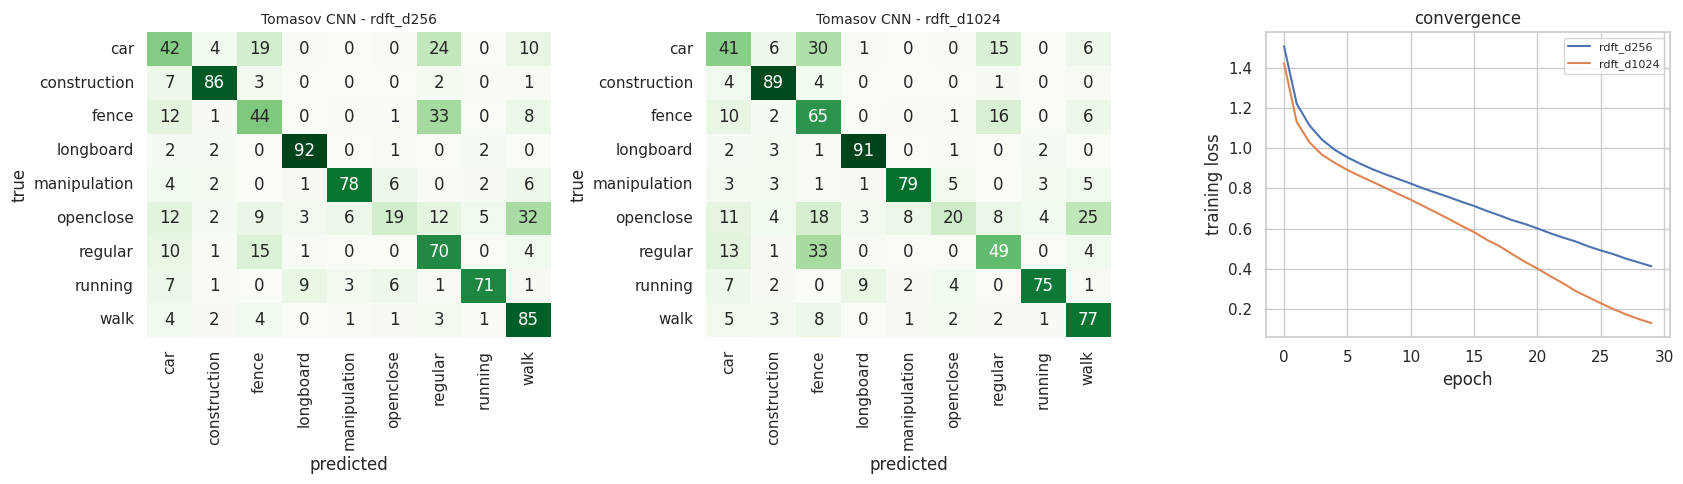

,class,precision,recall,f1-score,support
0,car,0.533,0.407,0.461,1772.000
1,construction,0.874,0.895,0.884,2232.000
2,fence,0.524,0.652,0.581,1983.000
3,longboard,0.813,0.914,0.861,581.000
4,manipulation,0.910,0.789,0.845,867.000
5,openclose,0.205,0.197,0.201,198.000
6,regular,0.455,0.494,0.474,1111.000
7,running,0.904,0.752,0.821,929.000
8,walk,0.772,0.769,0.771,1661.000
9,accuracy,0.687,0.687,0.687,0.687


In [5]:
if len(DENSE_UNITS) > 1:
    piv = res.pivot(index="transform", columns="dense_units", values="f1_macro")
    piv["diff_pp"] = (piv[1024] - piv[256]).round(2)
    display(piv.round(2))
    print("Positive diff_pp means the larger dense layer helped despite 4x the parameters.")

fig, axes = plt.subplots(1, len(confusions) + 1,
                         figsize=(5.5*len(confusions) + 6, 5))
axes = np.atleast_1d(axes)
for ax, (tag, cm) in zip(axes, confusions.items()):
    sns.heatmap(100*cm, annot=True, fmt=".0f", cmap="Greens", ax=ax, cbar=False)
    ax.set_title(f"Tomasov CNN - {tag}", fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
for tag, h in curves.items():
    axes[-1].plot(h, label=tag)
axes[-1].set_xlabel("epoch"); axes[-1].set_ylabel("training loss")
axes[-1].set_title("convergence"); axes[-1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(out_dir / "tomasov_cnn_confusion_and_loss.png", dpi=200, bbox_inches="tight")
plt.show()

# NOTE: `res.iloc[0].transform` returns pandas' Series.transform METHOD, not the
# column. Always use bracket access for a column named after a DataFrame method.
best_key = f"{res.iloc[0]['transform']}_d{int(res.iloc[0]['dense_units'])}"
display(per_class[best_key].round(3))
for k, v in per_class.items():
    v.to_csv(out_dir / f"tomasov_cnn_per_class_{k}.csv", index=False)
for k, v in confusions.items():
    v.to_csv(out_dir / f"tomasov_cnn_confusion_{k}.csv")

## 4. Head-to-head with the feature pipeline

Same dataset, same leakage-safe split. The `openclose` row is the one to read carefully:
the feature pipeline collapses on it (F1 0.044) once the leak is removed, so if the CNN
also collapses, that class is simply not learnable from this data - not a modelling
failure on either side.

In [6]:
rows = []
for variant in ("full_1002", "8_consensus"):
    p = C.results_dir("tomasov", "07_final") / variant / "model_card.json"
    if p.exists():
        card = json.loads(p.read_text())
        rows.append({"approach": f"Multi-domain features ({variant})",
                     "detail": f"{card['model']} / {card['n_features']} feat",
                     "accuracy": card["test"]["accuracy"],
                     "balanced_accuracy": card["test"]["balanced_accuracy"],
                     "f1_macro": card["test"]["f1_macro"]})
for _, r in res.iterrows():   # r is a Series; use r['col']
    rows.append({"approach": f"Tomasov CNN ({r['transform']}, dense {int(r['dense_units'])})",
                 "detail": f"{int(r['n_params']):,} params",
                 "accuracy": r["accuracy"], "balanced_accuracy": r["balanced_accuracy"],
                 "f1_macro": r["f1_macro"]})

head = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
display(head.round(2))
head.to_csv(out_dir / "tomasov_head_to_head.csv", index=False)

ref = pd.DataFrame([
    {"source": "Tomasov et al. 2025 (their own split)", "preproc": "MFCC", "accuracy": 85.61, "f1_macro": 84.72},
    {"source": "Tomasov et al. 2025 (their own split)", "preproc": "RDFT", "accuracy": 85.47, "f1_macro": 84.84},
    {"source": "Tomasov et al. 2025 (their own split)", "preproc": "DWT",  "accuracy": 78.48, "f1_macro": 75.84},
])
print("\nFor context - as published, on their own random split (8192 window, stride 256):")
display(ref)
ref.to_csv(out_dir / "tomasov_published_reference.csv", index=False)
print("Their split reused windows overlapping by 96.9%, so these are not directly")
print("comparable to the numbers above; they are the target our reproduction aims at.")

,approach,detail,accuracy,balanced_accuracy,f1_macro
0,Multi-domain features (full_1002),LightGBM / 1002 feat,90.71,81.97,81.98
1,Multi-domain features (8_consensus),LightGBM / 52 feat,77.29,72.88,73.59
2,"Tomasov CNN (rdft, dense 1024)","33,155,849 params",68.74,65.22,65.55
3,"Tomasov CNN (rdft, dense 256)","8,375,561 params",67.28,65.23,64.66



For context - as published, on their own random split (8192 window, stride 256):


,source,preproc,accuracy,f1_macro
0,Tomasov et al. 2025 (their own split),MFCC,85.61,84.72
1,Tomasov et al. 2025 (their own split),RDFT,85.47,84.84
2,Tomasov et al. 2025 (their own split),DWT,78.48,75.84


Their split reused windows overlapping by 96.9%, so these are not directly
comparable to the numbers above; they are the target our reproduction aims at.


## 5. Record the assumptions

Anything we inferred rather than read is written to disk, so the paper's methods section
can state it explicitly.

In [7]:
assumptions = {
    "source": "Tomasov et al., IEEE Access 13, 2025, Sections III-C, III-E, IV",
    "read_from_paper": {
        "conv_filters": [64, 256], "activation": "LeakyReLU",
        "pool_size": 4, "dense_units": 256, "dense_activation": "sigmoid",
        "output_activation": "softmax", "optimiser": "Adam",
        "class_weighted_loss": True, "split": "80/10/10",
        "rdft_bins": B.RDFT_BINS, "rdft_freq_range_hz": [0, 833],
        "dwt_level": B.DWT_LEVEL, "dwt_wavelet": B.DWT_WAVELET,
        "window": C.WIN_LEN, "their_stride": 256,
    },
    "inferred_or_substituted": {
        "kernel_size": "7, from Table 21 of our manuscript (not stated in the Access paper)",
        "rdft_redundancy": f"{B.RDFT_REDUNDANCY}, derived from 2048 bins <-> 0-833 Hz at fs=20 kHz",
        "epochs": EPOCHS, "batch_size": BATCH, "learning_rate": LR,
        "mfcc_params": f"n_mfcc={B.MFCC_N}, hop={B.MFCC_HOP}; librosa if importable, "
                       "otherwise an equivalent scipy mel/DCT implementation",
        "split": "our blocked spatio-temporal split, NOT their random 10-fold",
    },
    "our_dense_1024_variant": "reproduces Table 21 (33,155,849 params) for traceability",
}
(out_dir / "tomasov_cnn_assumptions.json").write_text(
    json.dumps(assumptions, indent=2), encoding="utf-8")
print(json.dumps(assumptions, indent=2))

{
  "source": "Tomasov et al., IEEE Access 13, 2025, Sections III-C, III-E, IV",
  "read_from_paper": {
    "conv_filters": [
      64,
      256
    ],
    "activation": "LeakyReLU",
    "pool_size": 4,
    "dense_units": 256,
    "dense_activation": "sigmoid",
    "output_activation": "softmax",
    "optimiser": "Adam",
    "class_weighted_loss": true,
    "split": "80/10/10",
    "rdft_bins": 2048,
    "rdft_freq_range_hz": [
      0,
      833
    ],
    "dwt_level": 3,
    "dwt_wavelet": "db4",
    "window": 8192,
    "their_stride": 256
  },
  "inferred_or_substituted": {
    "kernel_size": "7, from Table 21 of our manuscript (not stated in the Access paper)",
    "rdft_redundancy": "6, derived from 2048 bins <-> 0-833 Hz at fs=20 kHz",
    "epochs": 30,
    "batch_size": 256,
    "learning_rate": 0.0001,
    "mfcc_params": "n_mfcc=40, hop=512; librosa if importable, otherwise an equivalent scipy mel/DCT implementation",
    "split": "our blocked spatio-temporal split, NOT their 

---
### What to put in the paper

> The CNN baselines are the architectures published by each dataset's own authors. For
> Cao et al. we use their released implementation unchanged (2D CNN over the 10000x12
> record, 7,421 parameters, min-max scaling to 0-255). For Tomasov et al., who released
> no code, we transcribe the architecture from Section III-E of their paper and apply the
> RDFT front end of Section III-C, since that paper explicitly rejects raw time-domain
> input. Both are trained on the same leakage-safe splits as the feature pipeline, so the
> comparison isolates the model rather than the evaluation protocol.